Saving cv.jpg to cv (4).jpg


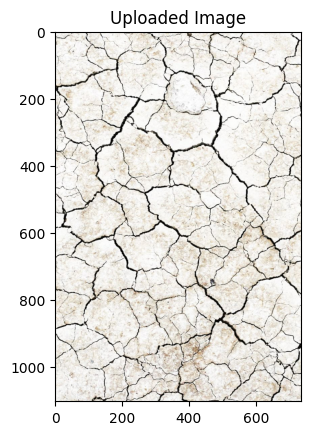

In [6]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Read image
image_name = list(uploaded.keys())[0]
img = cv2.imread(image_name)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded Image")
plt.show()

In [7]:
Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

In [8]:
Ixx = Ix * Ix
Iyy = Iy * Iy
Ixy = Ix * Iy

Sxx = cv2.GaussianBlur(Ixx, (3,3), 1)
Syy = cv2.GaussianBlur(Iyy, (3,3), 1)
Sxy = cv2.GaussianBlur(Ixy, (3,3), 1)

In [9]:
height, width = gray.shape

corner_img = img.copy()
edge_img = img.copy()
flat_img = img.copy()

threshold = 0.01

for y in range(height):
    for x in range(width):

        M = np.array([[Sxx[y,x], Sxy[y,x]],
                      [Sxy[y,x], Syy[y,x]]])

        eigenvalues, _ = np.linalg.eig(M)
        lambda1, lambda2 = eigenvalues

        if lambda1 > threshold and lambda2 > threshold:
            corner_img[y,x] = [0,0,255]  # Red

        elif (lambda1 > threshold and lambda2 <= threshold) or \
             (lambda2 > threshold and lambda1 <= threshold):
            edge_img[y,x] = [255,0,0]    # Blue

        else:
            flat_img[y,x] = [0,255,0]    # Green

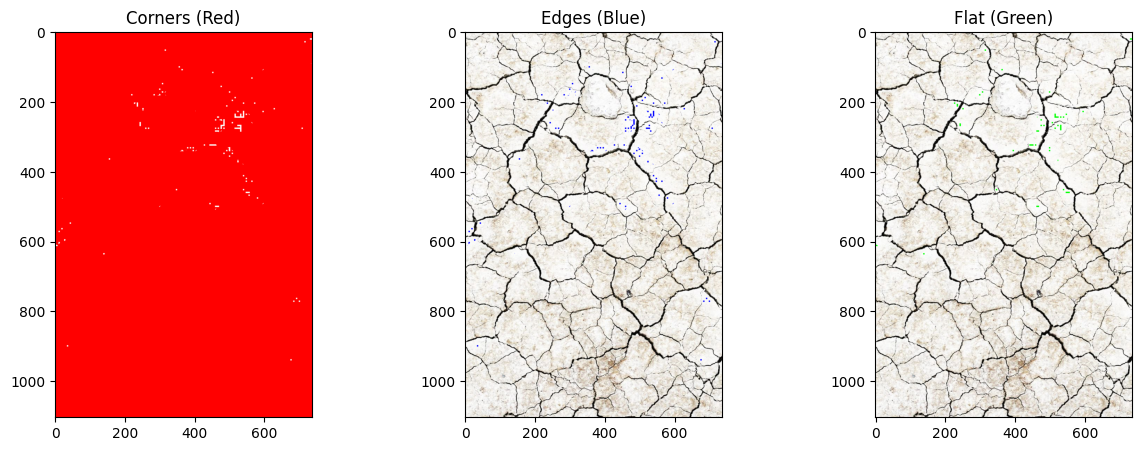

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Corners (Red)")
plt.imshow(cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Edges (Blue)")
plt.imshow(cv2.cvtColor(edge_img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,3)
plt.title("Flat (Green)")
plt.imshow(cv2.cvtColor(flat_img, cv2.COLOR_BGR2RGB))

plt.show()